# Segmentação Semântica

**Redes Neurais e Aprendizado Profundo - 2025.2**

Pipeline:
1. Treinamento da U-Net no Oxford-IIIT Pet
2. Avaliação: IoU e Acurácia (torchmetrics)
3. Visualização das predições e exportação do modelo (.tflite)

## Instalação

In [1]:
!pip install torchmetrics --quiet
!pip install onnx onnxruntime onnxscript --quiet
!pip install onnx2tf --quiet

## Imports e Configuração

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import torchmetrics
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# --- Hiperparâmetros ---
DATA_DIR        = "./data"
IMAGE_SIZE      = 128
BATCH_SIZE      = 16
NUM_CLASSES     = 3      # Oxford Pet: 0=Pet, 1=Fundo, 2=Borda
LEARNING_RATE   = 1e-3
NUM_EPOCHS     = 50
EARLY_STOPPING = 7
NUM_TRAIN = 2500
NUM_VAL   = 500

Device: cuda


## Parte 1 — Dataset e Treinamento

In [3]:
# Transforms
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

mask_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE),
                      interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
])

def process_mask(mask):
    # Oxford Pet usa índices 1,2,3 → convertemos para 0,1,2
    mask = torch.squeeze(mask) - 1
    return mask.long()

# Dataset completo
full_dataset = datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=image_transform,
    target_transform=lambda t: process_mask(mask_transform(t)),
)

# Subsets
indices = torch.randperm(len(full_dataset)).tolist()
train_dataset = Subset(full_dataset, indices[:NUM_TRAIN])
val_dataset   = Subset(full_dataset, indices[NUM_TRAIN:NUM_TRAIN + NUM_VAL])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 2500 | Val: 500


In [4]:
# --- Arquitetura U-Net ---

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    U-Net simplificada.
    features: lista de canais em cada nível do encoder.
    O bottleneck dobra o último valor.
    """
    def __init__(self, in_channels=3, num_classes=NUM_CLASSES, features=[64, 128]):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)

        # Encoder
        self.encoder = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoder.append(DoubleConv(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2, dropout=0.3)

        # Decoder
        self.decoder_up   = nn.ModuleList()
        self.decoder_conv = nn.ModuleList()
        ch = features[-1] * 2
        for f in reversed(features):
            self.decoder_up.append(
                nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2)
            )
            self.decoder_conv.append(DoubleConv(f * 2, f))
            ch = f

        # Saída
        self.head = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        skips = []

        # Encoder
        for enc in self.encoder:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]  # inverte para alinhar com o decoder

        # Decoder
        for up, conv, skip in zip(self.decoder_up, self.decoder_conv, skips):
            x = up(x)
            x = torch.cat([skip, x], dim=1)
            x = conv(x)

        return self.head(x)


# Sanity check de shape
model = UNet().to(DEVICE)
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
out   = model(dummy)
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}  (esperado: [2, {NUM_CLASSES}, {IMAGE_SIZE}, {IMAGE_SIZE}])")

Input:  torch.Size([2, 3, 128, 128])
Output: torch.Size([2, 3, 128, 128])  (esperado: [2, 3, 128, 128])


In [5]:
# --- Loop de Treinamento ---

def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience):
    model.to(DEVICE)
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        # --- Train ---
        model.train()
        running_loss = 0.0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]", leave=False):
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(images), masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # --- Val ---
        model.eval()
        running_loss = 0.0
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} [Val]", leave=False):
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                loss = criterion(model(images), masks)
                running_loss += loss.item() * images.size(0)
        val_loss = running_loss / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        elapsed = time.time() - t0
        print(f"Epoch {epoch:>2}/{num_epochs} | "
              f"{elapsed:.1f}s | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), "unet_best.pth")
            print(f"  -> checkpoint salvo (val_loss={best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping: {patience} epochs sem melhora na val loss.")
                break

    return history


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = train(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, EARLY_STOPPING)

Epoch  1/50 | 28.2s | Train Loss: 0.7266 | Val Loss: 0.7211
  -> checkpoint salvo (val_loss=0.7211)


Epoch  2/50 | 24.1s | Train Loss: 0.6237 | Val Loss: 0.5519
  -> checkpoint salvo (val_loss=0.5519)


Epoch  3/50 | 24.2s | Train Loss: 0.5710 | Val Loss: 0.4995
  -> checkpoint salvo (val_loss=0.4995)


Epoch  4/50 | 24.3s | Train Loss: 0.5284 | Val Loss: 0.5264


Epoch  5/50 | 25.3s | Train Loss: 0.5036 | Val Loss: 0.5075


...

Epoch 36/50 | 25.5s | Train Loss: 0.2720 | Val Loss: 0.3127


Epoch 37/50 | 25.4s | Train Loss: 0.2625 | Val Loss: 0.4235


Epoch 38/50 | 25.2s | Train Loss: 0.2631 | Val Loss: 0.3098


Epoch 39/50 | 25.0s | Train Loss: 0.2553 | Val Loss: 0.3181


Epoch 40/50 | 25.0s | Train Loss: 0.2538 | Val Loss: 0.3253

Early stopping: 7 epochs sem melhora na val loss.


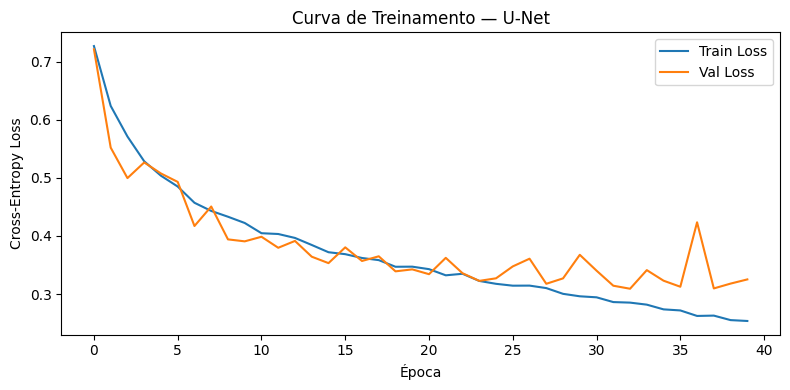

In [6]:
# Curva de loss
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"],   label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Cross-Entropy Loss")
plt.title("Curva de Treinamento — U-Net")
plt.legend()
plt.tight_layout()
plt.show()

## Parte 2 — Avaliação e Métricas

In [7]:
# Carrega o melhor checkpoint
model.load_state_dict(torch.load("unet_best.pth", map_location=DEVICE))
model.eval()

# Métricas globais
jaccard_macro  = torchmetrics.JaccardIndex(task="multiclass", num_classes=NUM_CLASSES, average="macro").to(DEVICE)
accuracy_macro = torchmetrics.Accuracy(task="multiclass",    num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# IoU por classe
jaccard_per_class = torchmetrics.JaccardIndex(task="multiclass", num_classes=NUM_CLASSES, average="none").to(DEVICE)

with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        preds = model(images)
        jaccard_macro.update(preds, masks)
        accuracy_macro.update(preds, masks)
        jaccard_per_class.update(preds, masks)

miou = jaccard_macro.compute()
acc  = accuracy_macro.compute()
iou_classes = jaccard_per_class.compute()

CLASS_NAMES = ["Pet", "Fundo", "Borda"]

print(f"mIoU     (val set completo): {miou.item():.4f}")
print(f"Acurácia (val set completo): {acc.item():.4f}")
print()
for i, (name, iou) in enumerate(zip(CLASS_NAMES, iou_classes)):
    print(f"  IoU classe {i} ({name}): {iou.item():.4f}")

mIoU     (val set completo): 0.7022
Acurácia (val set completo): 0.8053

  IoU classe 0 (Pet): 0.7757
  IoU classe 1 (Fundo): 0.8696
  IoU classe 2 (Borda): 0.4612


## Parte 3 — Visualização dos Resultados

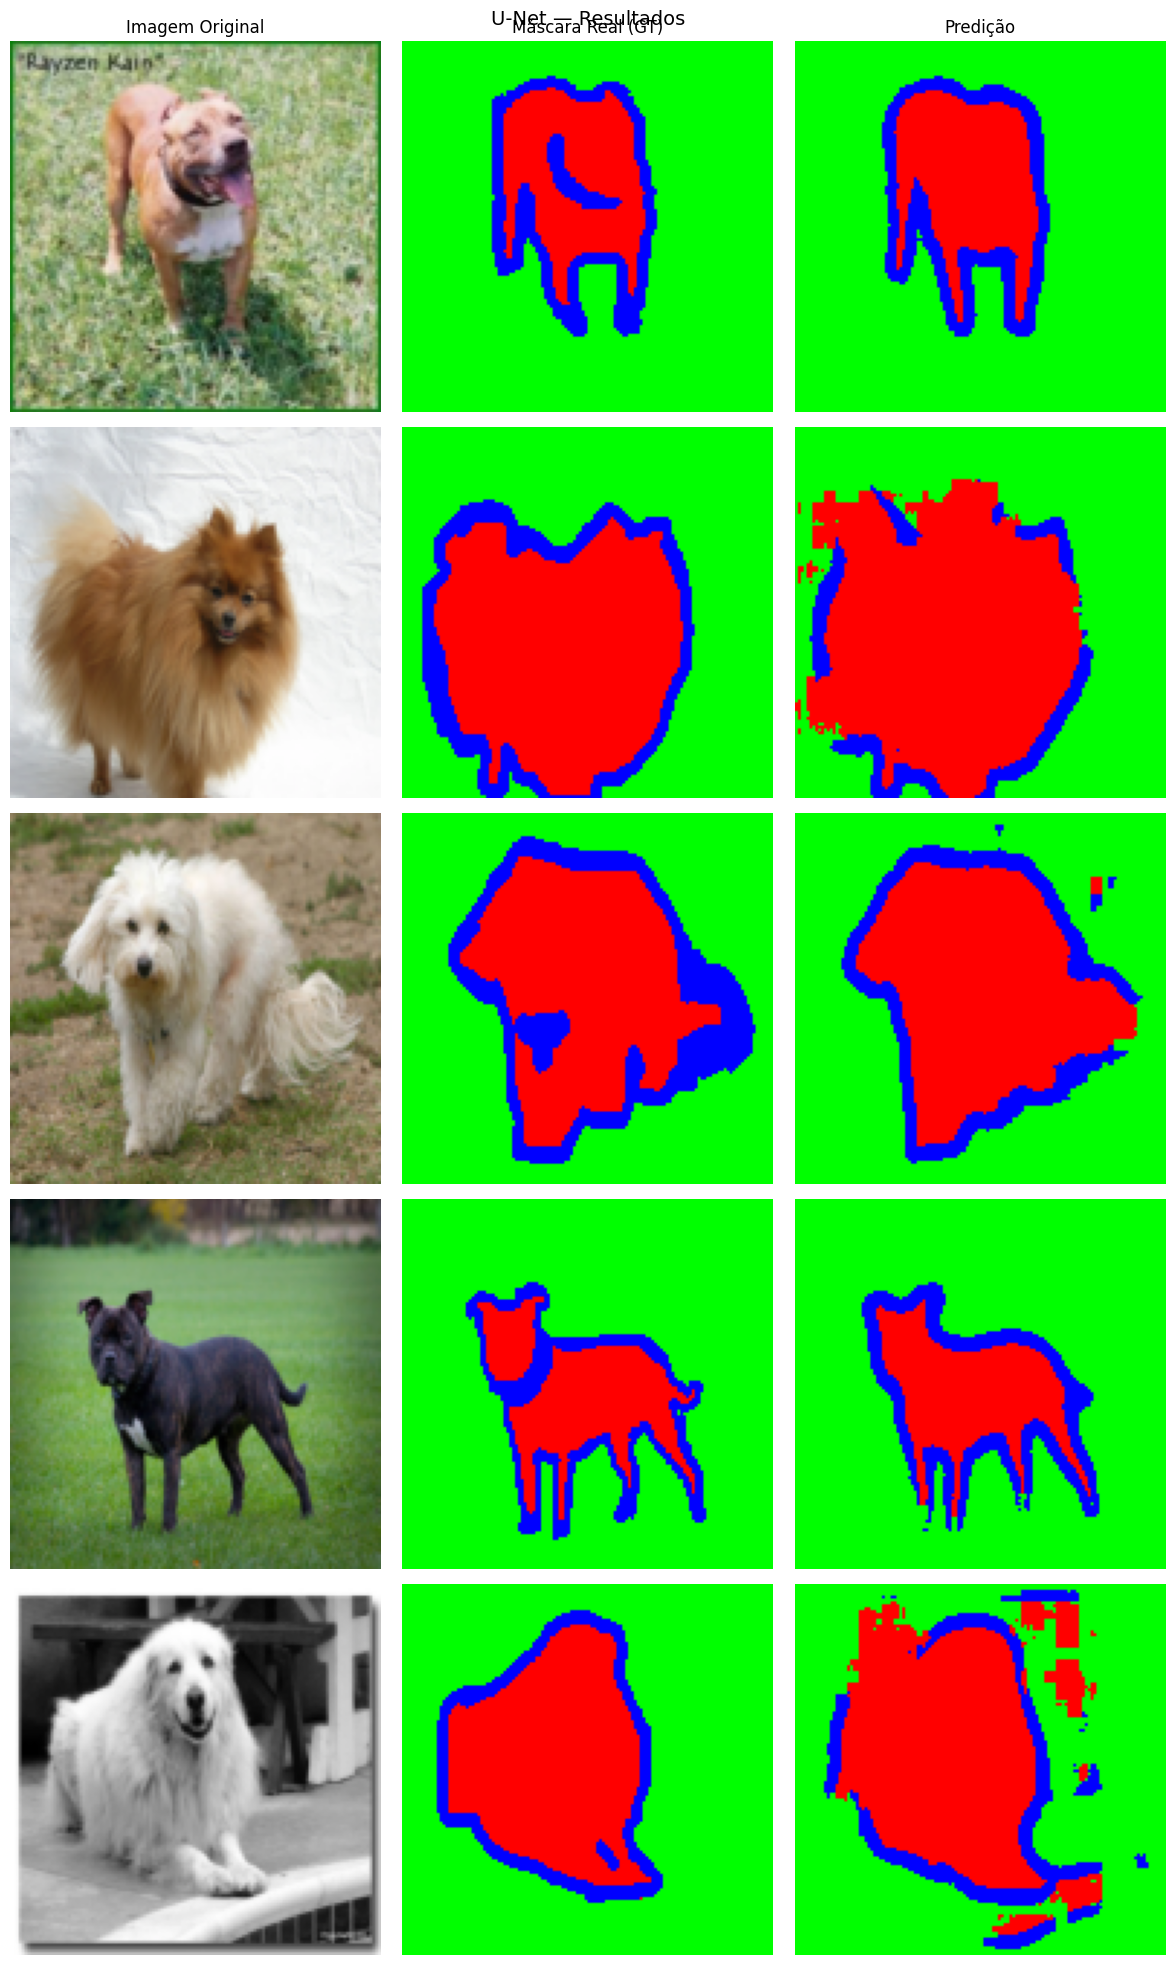

In [8]:
# Paleta de cores para as 3 classes
COLORS = np.array([
    [255,  0,  0],   # 0 = Pet   → vermelho
    [  0,255,  0],   # 1 = Fundo → verde
    [  0,  0,255],   # 2 = Borda → azul
], dtype=np.uint8)

def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

def mask_to_rgb(mask_2d):
    """mask_2d: (H, W) tensor com valores 0,1,2 → numpy (H, W, 3)"""
    h, w = mask_2d.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in enumerate(COLORS):
        rgb[mask_2d.numpy() == cls] = color
    return rgb


def visualize(model, loader, n=5):
    model.eval()
    images, masks = next(iter(loader))
    images, masks = images.to(DEVICE), masks.to(DEVICE)

    with torch.no_grad():
        preds = torch.argmax(model(images), dim=1).cpu()

    images = images.cpu()
    masks  = masks.cpu()

    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    fig.suptitle("U-Net — Resultados", fontsize=14)
    cols = ["Imagem Original", "Máscara Real (GT)", "Predição"]

    for i in range(n):
        img_np  = unnormalize(images[i]).permute(1, 2, 0).numpy()
        gt_rgb  = mask_to_rgb(masks[i])
        pr_rgb  = mask_to_rgb(preds[i])

        for ax, data, title in zip(axes[i], [img_np, gt_rgb, pr_rgb], cols):
            ax.imshow(data)
            ax.axis("off")
            if i == 0:
                ax.set_title(title)

    plt.tight_layout()
    plt.show()


visualize(model, val_loader, n=5)

## Exportação para TFLite (deploy Android)

Usando `ai-edge-torch` para converter diretamente de PyTorch para `.tflite`.

In [9]:
import onnx
import onnxruntime as ort
import numpy as np

model_cpu = UNet().cpu()
model_cpu.load_state_dict(torch.load("unet_best.pth", map_location="cpu"))
model_cpu.eval()

sample_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)

torch.onnx.export(
    model_cpu,
    sample_input,
    "unet_segmentation.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=12,
)
print("Exportado: unet_segmentation.onnx")

with torch.no_grad():
    pt_out = model_cpu(sample_input).numpy()

session = ort.InferenceSession("unet_segmentation.onnx")
onnx_out = session.run(["output"], {"input": sample_input.numpy()})[0]

max_diff = np.abs(pt_out - onnx_out).max()
print(f"Diferença máxima PyTorch vs ONNX: {max_diff:.6f}")
print("OK" if max_diff < 1e-4 else "ATENÇÃO: diferença acima do esperado")

W0603 17:27:33.399000 40262 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `UNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `UNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 20 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
Exportado: unet_segmentation.onnx
Diferença máxima PyTorch vs ONNX: 0.000004
OK


In [10]:
import onnx2tf

onnx2tf.convert(
    input_onnx_file_path="unet_segmentation.onnx",
    output_folder_path="unet_saved_model",
    non_verbose=True,
)
print("TFLite gerado.")

flatbuffer_direct lowering:   0%|          | 0/27 [00:00<?, ?it/s]

flatbuffer_direct post-lowering:   0%|          | 0/6 [00:00<?, ?it/s]

flatbuffer_direct export:   0%|          | 0/3 [00:00<?, ?it/s]

flatbuffer_direct write timing: stage=float32 mode=builder_direct total=0.035s serialize=0.025s (sanitize=0.000s build=0.002s pack=0.017s output=0.005s) write=0.010s size=7.11MB
flatbuffer_direct write timing: stage=float16 mode=builder_direct total=0.015s serialize=0.012s (sanitize=0.000s build=0.002s pack=0.009s output=0.000s) write=0.003s size=3.56MB
TFLite gerado.


In [12]:
import shutil
from google.colab import files

shutil.copy("unet_saved_model/unet_segmentation_float32.tflite", "unet_segmentation.tflite")
files.download("unet_segmentation.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>